# Analisis Hasil Hyperparameter Tuning Model Segmentasi Banjir

Notebook ini menganalisis hasil training hyperparameter tuning grid search untuk dua arsitektur model:
1. **U-Net**
2. **ProCANet**

Masing-masing model ditraining menggunakan **5-Fold Spatial Cross-Validation** (Fold 0-4) pada 6 variasi hyperparameter (kombinasi `lr` dan `weight_decay`):
- `grid_lr_1e-4_wd_1e-4` (lr=1e-4, wd=1e-4)
- `grid_lr_1e-4_wd_1e-5` (lr=1e-4, wd=1e-5)
- `grid_lr_5e-5_wd_1e-4` (lr=5e-5, wd=1e-4)
- `grid_lr_5e-5_wd_1e-5` (lr=5e-5, wd=1e-5)
- `grid_lr_1e-5_wd_1e-4` (lr=1e-5, wd=1e-4)
- `grid_lr_1e-5_wd_1e-5` (lr=1e-5, wd=1e-5)

Total terdapat **60 training runs** (2 model * 5 fold * 6 variasi). Evaluasi dilakukan berdasarkan metrik **Mean Validation Intersection over Union (IoU)** dan **Mean Validation Dice Coefficient**.

In [1]:
import json
import csv
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11

# Tentukan root path project
ROOT_DIR = Path.cwd().resolve()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent

RUNS_DIR = ROOT_DIR / "runs"
print(f"Directory runs: {RUNS_DIR} (Exists: {RUNS_DIR.exists()})")

Directory runs: /home/nozomi/Productive/skripsi/runs (Exists: True)


## 1. Load Data Eksperimen

Kita akan meload semua data `config.json` dan `metrics.csv` dari folder `runs` secara rekursif, kemudian mengekstrak metrik evaluasi terbaik untuk setiap run (berdasarkan Epoch dengan Validation IoU tertinggi).

In [2]:
def load_hyperparameter_tuning_results(runs_dir):
    results = []
    
    # Cari config.json rekursif
    for config_path in sorted(runs_dir.glob("**/config.json")):
        folder = config_path.parent
        metrics_path = folder / "metrics.csv"
        
        if not metrics_path.exists():
            continue
            
        # Load config
        with open(config_path, "r") as f:
            config = json.load(f)
            
        arch = config.get("architecture")
        fold = config.get("fold")
        variant = config.get("tuning_variant")
        lr = config.get("lr")
        wd = config.get("weight_decay")
        
        # Load metrics.csv
        try:
            df_metrics = pd.read_csv(metrics_path)
            if df_metrics.empty:
                continue
                
            # Cari baris dengan val_iou tertinggi (checkpoint terbaik)
            best_idx = df_metrics["val_iou"].idxmax()
            best_row = df_metrics.loc[best_idx]
            
            last_row = df_metrics.iloc[-1]
            total_epochs = len(df_metrics)
            stopped_early = bool(last_row.get("stopped_early", 0))
            
            results.append({
                "architecture": arch,
                "fold": fold,
                "variant": variant,
                "lr": lr,
                "weight_decay": wd,
                "best_epoch": int(best_row["epoch"]),
                "best_val_iou": float(best_row["val_iou"]),
                "best_val_dice": float(best_row["val_dice"]),
                "best_val_loss": float(best_row["val_loss"]),
                "best_train_iou": float(best_row["train_iou"]),
                "best_train_dice": float(best_row["train_dice"]),
                "best_train_loss": float(best_row["train_loss"]),
                "total_epochs": total_epochs,
                "stopped_early": stopped_early,
                "metrics_path": str(metrics_path)
            })
        except Exception as e:
            print(f"Error reading {metrics_path}: {e}")
            
    return pd.DataFrame(results)

df_results = load_hyperparameter_tuning_results(RUNS_DIR)
print(f"Berhasil memuat {len(df_results)} runs dari direktori output.")

Error reading /home/nozomi/Productive/skripsi/runs/final/procanet/metrics.csv: 'val_iou'
Error reading /home/nozomi/Productive/skripsi/runs/final/unet/metrics.csv: 'val_iou'
Berhasil memuat 60 runs dari direktori output.


In [3]:
# Validasi jumlah runs per model dan variasi (masing-masing kombinasi harus memiliki 5 fold)
if not df_results.empty:
    summary_counts = df_results.groupby(["architecture", "variant"]).size().unstack(fill_value=0)
    print("Jumlah run per arsitektur dan variasi (harus bernilai 5 untuk masing-masing fold):")
    display(summary_counts)
else:
    print("Dataframe hasil kosong. Silakan periksa direktori runs Anda.")

Jumlah run per arsitektur dan variasi (harus bernilai 5 untuk masing-masing fold):


variant,grid_lr_1e-4_wd_1e-4,grid_lr_1e-4_wd_1e-5,grid_lr_1e-5_wd_1e-4,grid_lr_1e-5_wd_1e-5,grid_lr_5e-5_wd_1e-4,grid_lr_5e-5_wd_1e-5
architecture,,,,,,
procanet,5,5,5,5,5,5
unet,5,5,5,5,5,5


## 2. Agregasi Performansi Per Variasi Hyperparameter

Kita menghitung nilai rata-rata (mean) dan standar deviasi (std) untuk `Validation IoU` dan `Validation Dice` dari kelima fold di setiap variasi hyperparameter. Hasilnya kemudian diurutkan berdasarkan `Mean Validation IoU` tertinggi.

In [4]:
if not df_results.empty:
    # Agregasi data
    agg_df = df_results.groupby(["architecture", "variant", "lr", "weight_decay"]).agg(
        mean_val_iou=("best_val_iou", "mean"),
        std_val_iou=("best_val_iou", "std"),
        mean_val_dice=("best_val_dice", "mean"),
        std_val_dice=("best_val_dice", "std"),
        mean_train_iou=("best_train_iou", "mean"),
        mean_val_loss=("best_val_loss", "mean"),
        mean_train_loss=("best_train_loss", "mean"),
        avg_best_epoch=("best_epoch", "mean"),
        avg_total_epochs=("total_epochs", "mean"),
        count_runs=("fold", "count")
    ).reset_index()

    # Tampilkan ringkasan U-Net
    print("=== RINGKASAN PERFORMANCE U-NET ===")
    unet_summary = agg_df[agg_df["architecture"] == "unet"].sort_values(by="mean_val_iou", ascending=False)
    display(unet_summary)

    # Tampilkan ringkasan ProCANet
    print("\n=== RINGKASAN PERFORMANCE PROCANET ===")
    procanet_summary = agg_df[agg_df["architecture"] == "procanet"].sort_values(by="mean_val_iou", ascending=False)
    display(procanet_summary)
else:
    print("Dataframe kosong.")

=== RINGKASAN PERFORMANCE U-NET ===


,architecture,variant,lr,weight_decay,mean_val_iou,std_val_iou,mean_val_dice,std_val_dice,mean_train_iou,mean_val_loss,mean_train_loss,avg_best_epoch,avg_total_epochs,count_runs
10,unet,grid_lr_5e-5_wd_1e-4,0.00005,0.00010,0.642336,0.167470,0.771095,0.136785,0.683599,0.770414,0.540023,21.2,31.2,5
7,unet,grid_lr_1e-4_wd_1e-5,0.00010,0.00001,0.638076,0.163852,0.768464,0.132797,0.690285,0.720479,0.435477,20.4,30.4,5
11,unet,grid_lr_5e-5_wd_1e-5,0.00005,0.00001,0.637268,0.170264,0.766844,0.139946,0.680298,0.785387,0.589665,16.0,26.0,5
6,unet,grid_lr_1e-4_wd_1e-4,0.00010,0.00010,0.630595,0.183078,0.759639,0.154303,0.710501,0.706666,0.376204,21.4,31.4,5
8,unet,grid_lr_1e-5_wd_1e-4,0.00001,0.00010,0.608386,0.153888,0.746509,0.131061,0.651338,0.926067,0.851254,23.4,33.4,5
9,unet,grid_lr_1e-5_wd_1e-5,0.00001,0.00001,0.552798,0.284198,0.665823,0.316295,0.533595,0.989187,0.972224,16.8,24.8,5



=== RINGKASAN PERFORMANCE PROCANET ===


,architecture,variant,lr,weight_decay,mean_val_iou,std_val_iou,mean_val_dice,std_val_dice,mean_train_iou,mean_val_loss,mean_train_loss,avg_best_epoch,avg_total_epochs,count_runs
0,procanet,grid_lr_1e-4_wd_1e-4,0.00010,0.00010,0.653125,0.172251,0.778533,0.140022,0.667914,0.707865,0.456668,18.4,28.4,5
1,procanet,grid_lr_1e-4_wd_1e-5,0.00010,0.00001,0.649184,0.177177,0.774832,0.145274,0.703234,0.671351,0.356266,14.6,24.6,5
5,procanet,grid_lr_5e-5_wd_1e-5,0.00005,0.00001,0.648864,0.156262,0.777613,0.124733,0.693918,0.749445,0.507930,19.2,29.2,5
4,procanet,grid_lr_5e-5_wd_1e-4,0.00005,0.00010,0.640883,0.176156,0.768751,0.144753,0.718343,0.731853,0.439825,23.0,33.0,5
2,procanet,grid_lr_1e-5_wd_1e-4,0.00001,0.00010,0.619554,0.144583,0.756513,0.120367,0.654283,0.956861,0.872244,17.0,27.0,5
3,procanet,grid_lr_1e-5_wd_1e-5,0.00001,0.00001,0.618258,0.145909,0.755423,0.120613,0.668696,0.888990,0.762489,20.8,30.8,5


## 3. Konfigurasi Terbaik untuk Setiap Arsitektur

Kita mengidentifikasi kombinasi hyperparameter optimal untuk masing-masing model berdasarkan nilai rata-rata Validation IoU tertinggi di seluruh fold.

In [5]:
if not df_results.empty:
    best_unet = unet_summary.iloc[0]
    best_procanet = procanet_summary.iloc[0]

    print(f"=== U-Net Terbaik ===")
    print(f"  - Variasi          : {best_unet['variant']}")
    print(f"  - Learning Rate    : {best_unet['lr']}")
    print(f"  - Weight Decay     : {best_unet['weight_decay']}")
    print(f"  - Mean Val IoU     : {best_unet['mean_val_iou']:.4f} ± {best_unet['std_val_iou']:.4f}")
    print(f"  - Mean Val Dice    : {best_unet['mean_val_dice']:.4f} ± {best_unet['std_val_dice']:.4f}")
    print(f"  - Avg Best Epoch   : {best_unet['avg_best_epoch']:.1f} (dari avg total {best_unet['avg_total_epochs']:.1f} epochs)")

    print(f"\n=== ProCANet Terbaik ===")
    print(f"  - Variasi          : {best_procanet['variant']}")
    print(f"  - Learning Rate    : {best_procanet['lr']}")
    print(f"  - Weight Decay     : {best_procanet['weight_decay']}")
    print(f"  - Mean Val IoU     : {best_procanet['mean_val_iou']:.4f} ± {best_procanet['std_val_iou']:.4f}")
    print(f"  - Mean Val Dice    : {best_procanet['mean_val_dice']:.4f} ± {best_procanet['std_val_dice']:.4f}")
    print(f"  - Avg Best Epoch   : {best_procanet['avg_best_epoch']:.1f} (dari avg total {best_procanet['avg_total_epochs']:.1f} epochs)")
else:
    print("Dataframe kosong.")

=== U-Net Terbaik ===
  - Variasi          : grid_lr_5e-5_wd_1e-4
  - Learning Rate    : 5e-05
  - Weight Decay     : 0.0001
  - Mean Val IoU     : 0.6423 ± 0.1675
  - Mean Val Dice    : 0.7711 ± 0.1368
  - Avg Best Epoch   : 21.2 (dari avg total 31.2 epochs)

=== ProCANet Terbaik ===
  - Variasi          : grid_lr_1e-4_wd_1e-4
  - Learning Rate    : 0.0001
  - Weight Decay     : 0.0001
  - Mean Val IoU     : 0.6531 ± 0.1723
  - Mean Val Dice    : 0.7785 ± 0.1400
  - Avg Best Epoch   : 18.4 (dari avg total 28.4 epochs)


## 4. Visualisasi Pengaruh Hyperparameter

### Boxplot Perbandingan Performansi Variasi Hyperparameter
Boxplot di bawah menunjukkan rentang dan variabilitas Validation IoU untuk keenam variasi hyperparameter di seluruh fold.

/tmp/ipykernel_112768/1581365785.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_112768/1581365785.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_112768/1581365785.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_112768/1581365785.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")


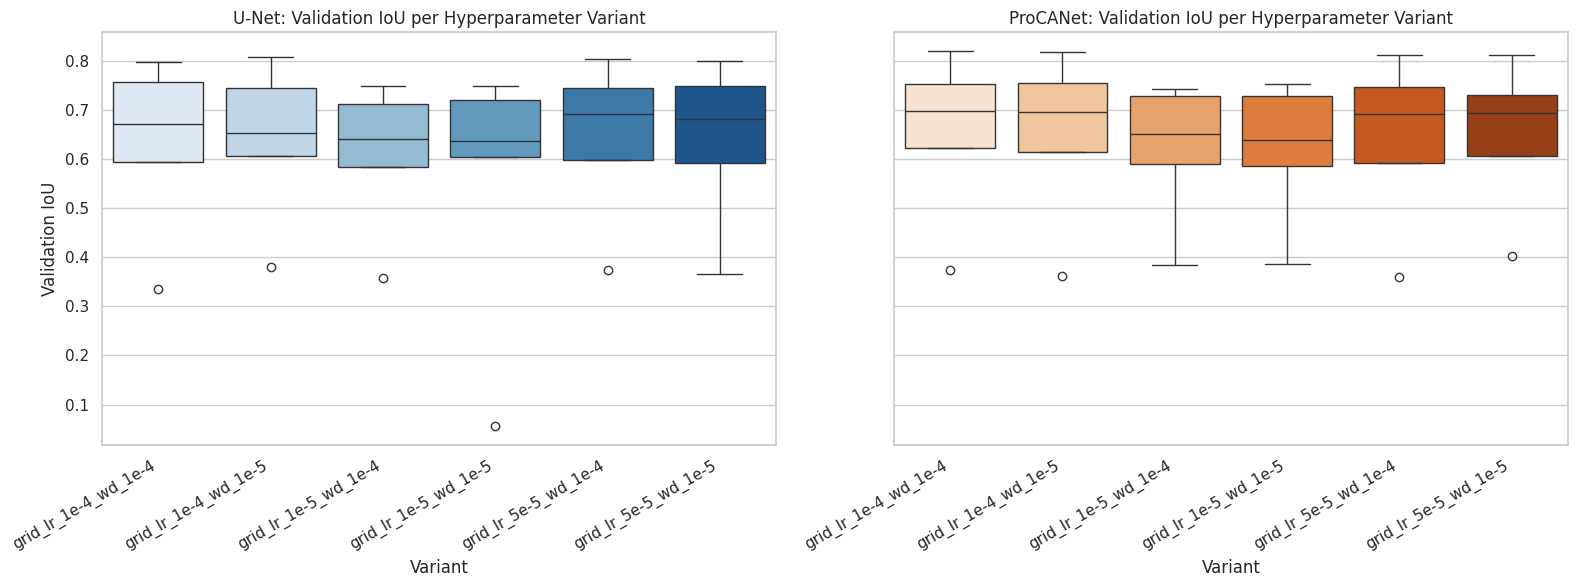

In [6]:
if not df_results.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # Plot U-Net
    sns.boxplot(
        data=df_results[df_results["architecture"] == "unet"],
        x="variant",
        y="best_val_iou",
        ax=axes[0],
        palette="Blues"
    )
    axes[0].set_title("U-Net: Validation IoU per Hyperparameter Variant")
    axes[0].set_xlabel("Variant")
    axes[0].set_ylabel("Validation IoU")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

    # Plot ProCANet
    sns.boxplot(
        data=df_results[df_results["architecture"] == "procanet"],
        x="variant",
        y="best_val_iou",
        ax=axes[1],
        palette="Oranges"
    )
    axes[1].set_title("ProCANet: Validation IoU per Hyperparameter Variant")
    axes[1].set_xlabel("Variant")
    axes[1].set_ylabel("")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")

    plt.tight_layout()
    plt.show()
else:
    print("Dataframe kosong.")

### Pengaruh Terpisah Learning Rate dan Weight Decay
Visualisasi ini memperlihatkan efek marginal dari masing-masing komponen hyperparameter terhadap Validation IoU rata-rata.

/tmp/ipykernel_112768/1347688748.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_112768/1347688748.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_112768/1347688748.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_112768/1347688748.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


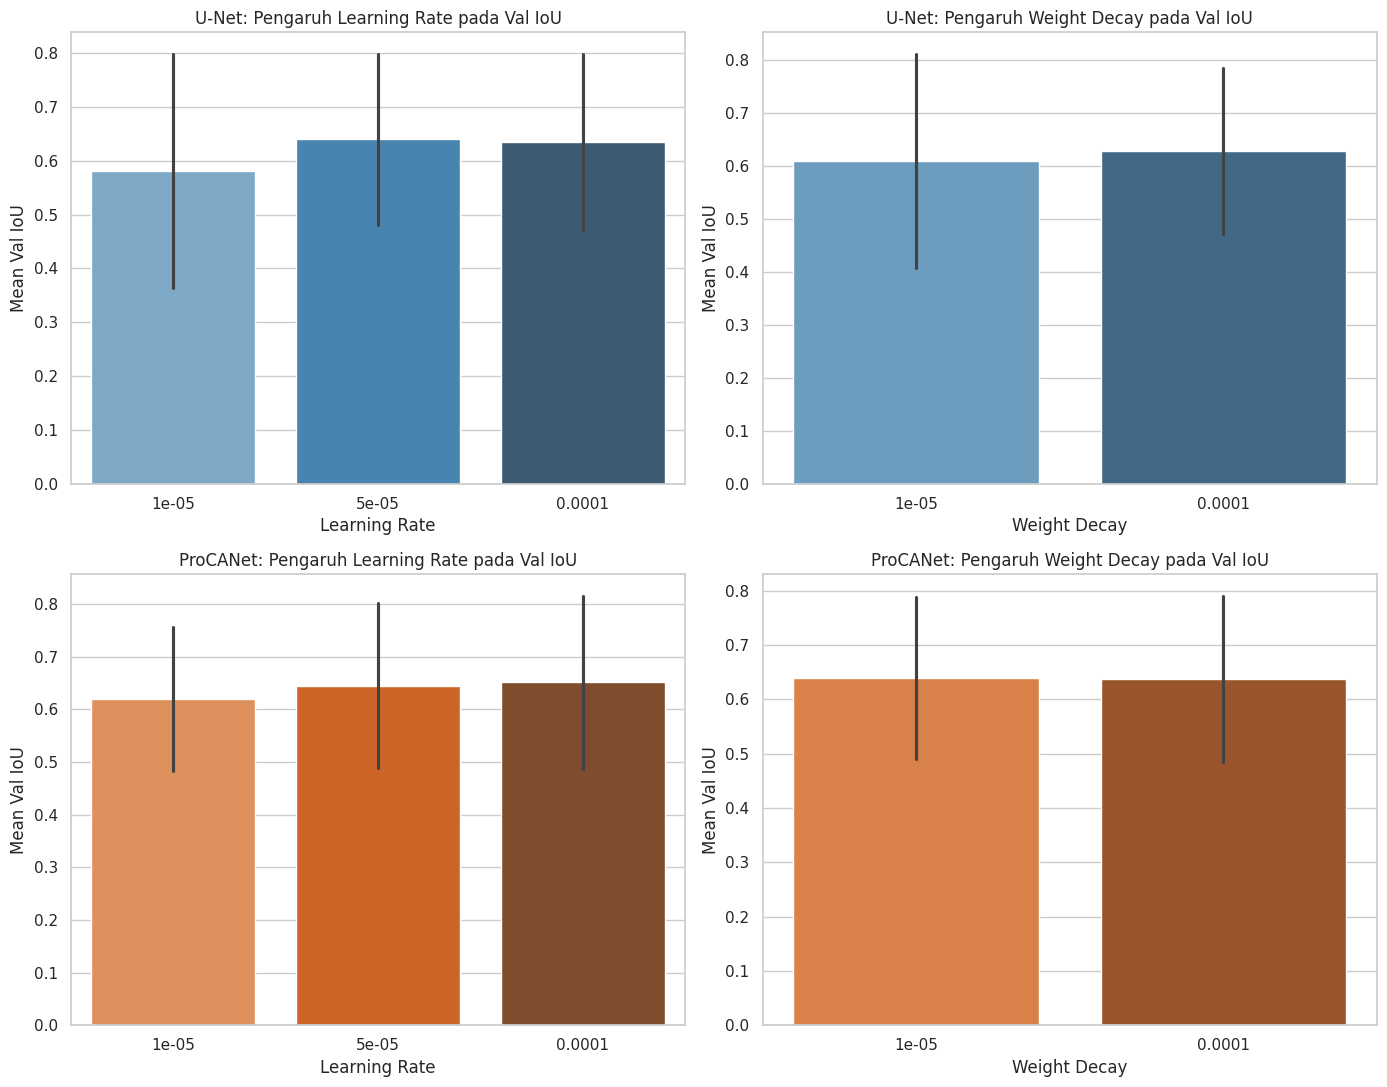

In [7]:
if not df_results.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))

    # U-Net: LR vs Val IoU
    sns.barplot(
        data=df_results[df_results["architecture"] == "unet"],
        x="lr",
        y="best_val_iou",
        ax=axes[0, 0],
        palette="Blues_d",
        errorbar="sd"
    )
    axes[0, 0].set_title("U-Net: Pengaruh Learning Rate pada Val IoU")
    axes[0, 0].set_xlabel("Learning Rate")
    axes[0, 0].set_ylabel("Mean Val IoU")

    # U-Net: WD vs Val IoU
    sns.barplot(
        data=df_results[df_results["architecture"] == "unet"],
        x="weight_decay",
        y="best_val_iou",
        ax=axes[0, 1],
        palette="Blues_d",
        errorbar="sd"
    )
    axes[0, 1].set_title("U-Net: Pengaruh Weight Decay pada Val IoU")
    axes[0, 1].set_xlabel("Weight Decay")
    axes[0, 1].set_ylabel("Mean Val IoU")

    # ProCANet: LR vs Val IoU
    sns.barplot(
        data=df_results[df_results["architecture"] == "procanet"],
        x="lr",
        y="best_val_iou",
        ax=axes[1, 0],
        palette="Oranges_d",
        errorbar="sd"
    )
    axes[1, 0].set_title("ProCANet: Pengaruh Learning Rate pada Val IoU")
    axes[1, 0].set_xlabel("Learning Rate")
    axes[1, 0].set_ylabel("Mean Val IoU")

    # ProCANet: WD vs Val IoU
    sns.barplot(
        data=df_results[df_results["architecture"] == "procanet"],
        x="weight_decay",
        y="best_val_iou",
        ax=axes[1, 1],
        palette="Oranges_d",
        errorbar="sd"
    )
    axes[1, 1].set_title("ProCANet: Pengaruh Weight Decay pada Val IoU")
    axes[1, 1].set_xlabel("Weight Decay")
    axes[1, 1].set_ylabel("Mean Val IoU")

    plt.tight_layout()
    plt.show()
else:
    print("Dataframe kosong.")

## 5. Analisis Kurva Training & Validasi (Rata-rata 5 Fold)

Kita memplot pergerakan Loss dan IoU/Dice rata-rata dari 5 fold di setiap epoch untuk konfigurasi terbaik. Untuk menangani panjang run yang berbeda karena Early Stopping, kita menyelaraskan epoch dengan mem-pad nilai metrik dari fold yang berhenti lebih awal menggunakan baris data terakhirnya (forward fill).

In [8]:
def get_average_learning_curves(df_results, architecture, variant):
    # Ambil hasil run yang cocok
    df_variant = df_results[(df_results["architecture"] == architecture) & (df_results["variant"] == variant)]
    if df_variant.empty:
        return pd.DataFrame()
        
    all_metrics = []
    max_epochs = 0
    
    # Baca file csv masing-masing fold
    for _, row in df_variant.iterrows():
        df_metric = pd.read_csv(row["metrics_path"])
        all_metrics.append(df_metric)
        max_epochs = max(max_epochs, len(df_metric))
        
    # Hitung rata-rata epoch per epoch
    aligned_metrics = []
    for epoch in range(1, max_epochs + 1):
        epoch_data = []
        for df_metric in all_metrics:
            if epoch > len(df_metric):
                row_data = df_metric.iloc[-1].copy()
                # Untuk training loss/iou, set tetap sama tapi stopped_early = 1
            else:
                row_data = df_metric[df_metric["epoch"] == epoch].iloc[0]
            epoch_data.append(row_data)
            
        df_epoch = pd.DataFrame(epoch_data)
        aligned_metrics.append({
            "epoch": epoch,
            "mean_train_loss": df_epoch["train_loss"].mean(),
            "mean_val_loss": df_epoch["val_loss"].mean(),
            "mean_train_iou": df_epoch["train_iou"].mean(),
            "mean_val_iou": df_epoch["val_iou"].mean(),
            "mean_train_dice": df_epoch["train_dice"].mean(),
            "mean_val_dice": df_epoch["val_dice"].mean()
        })
        
    return pd.DataFrame(aligned_metrics)

if not df_results.empty:
    best_unet_curve = get_average_learning_curves(df_results, "unet", best_unet["variant"])
    best_procanet_curve = get_average_learning_curves(df_results, "procanet", best_procanet["variant"])
    print("Kurva training berhasil dihitung untuk kedua model terbaik.")
else:
    print("Dataframe kosong.")

Kurva training berhasil dihitung untuk kedua model terbaik.


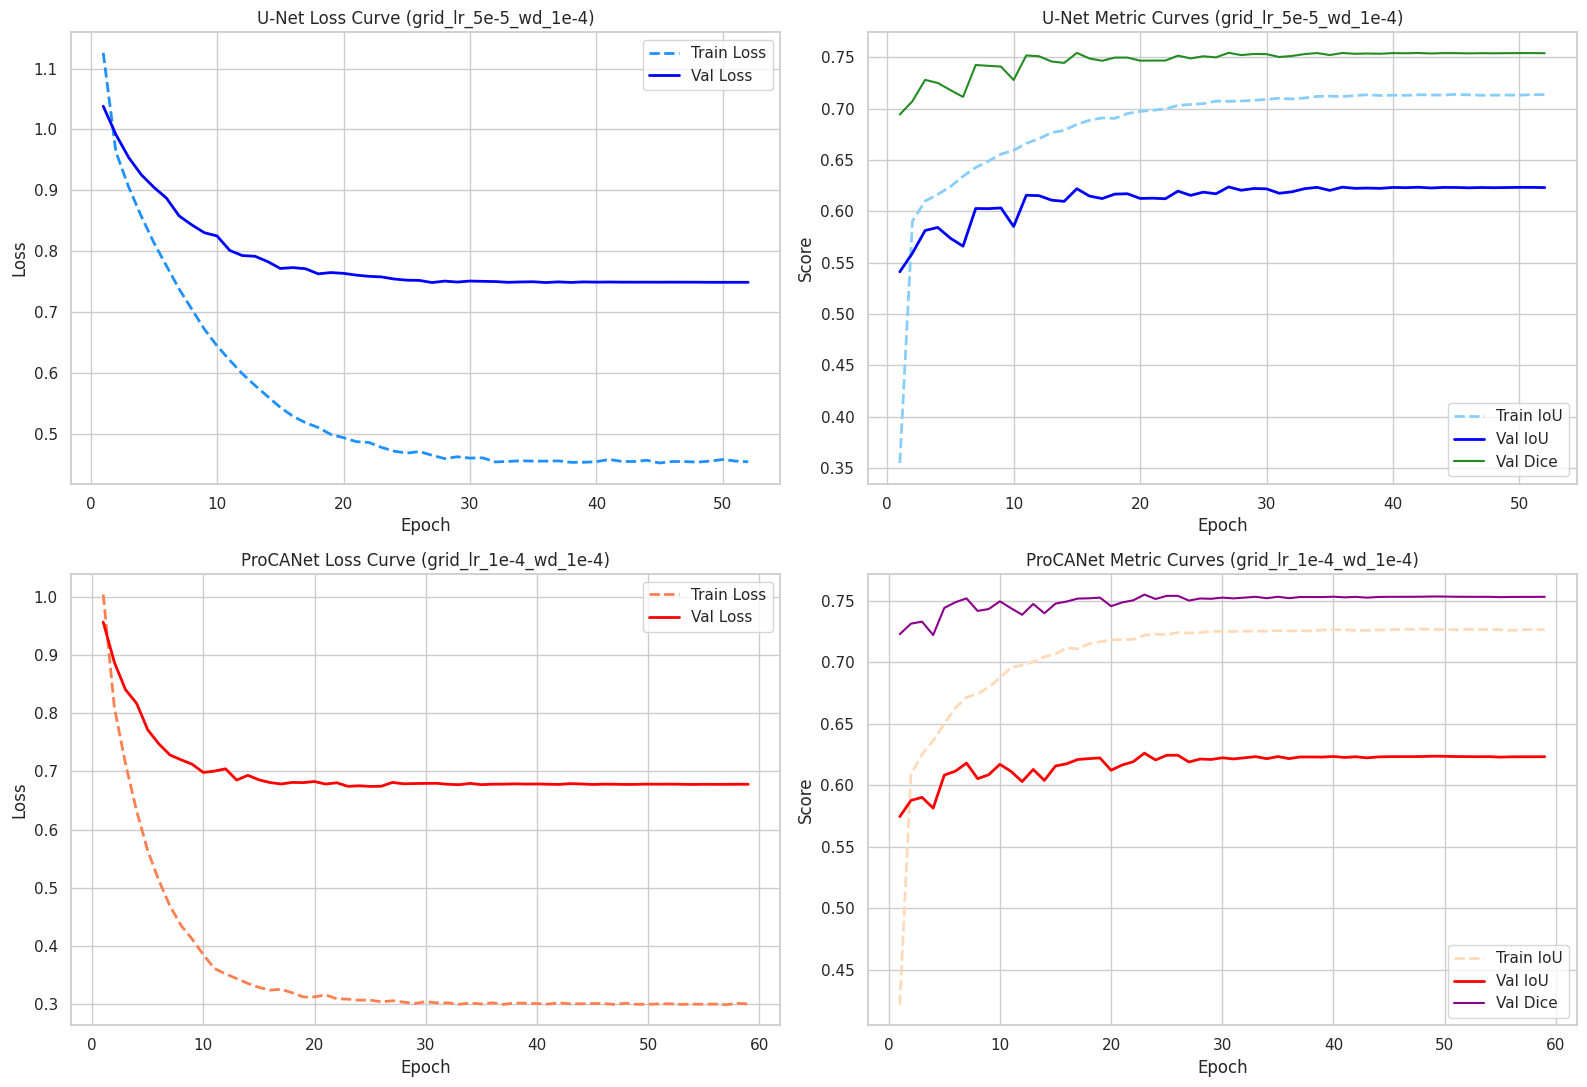

In [9]:
if not df_results.empty and not best_unet_curve.empty and not best_procanet_curve.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    # U-Net Loss
    axes[0, 0].plot(best_unet_curve["epoch"], best_unet_curve["mean_train_loss"], label="Train Loss", color="dodgerblue", linestyle="--", linewidth=2)
    axes[0, 0].plot(best_unet_curve["epoch"], best_unet_curve["mean_val_loss"], label="Val Loss", color="blue", linewidth=2)
    axes[0, 0].set_title(f"U-Net Loss Curve ({best_unet['variant']})")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    # U-Net Metric
    axes[0, 1].plot(best_unet_curve["epoch"], best_unet_curve["mean_train_iou"], label="Train IoU", color="lightskyblue", linestyle="--", linewidth=2)
    axes[0, 1].plot(best_unet_curve["epoch"], best_unet_curve["mean_val_iou"], label="Val IoU", color="blue", linewidth=2)
    axes[0, 1].plot(best_unet_curve["epoch"], best_unet_curve["mean_val_dice"], label="Val Dice", color="forestgreen", linewidth=1.5)
    axes[0, 1].set_title(f"U-Net Metric Curves ({best_unet['variant']})")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Score")
    axes[0, 1].legend()

    # ProCANet Loss
    axes[1, 0].plot(best_procanet_curve["epoch"], best_procanet_curve["mean_train_loss"], label="Train Loss", color="coral", linestyle="--", linewidth=2)
    axes[1, 0].plot(best_procanet_curve["epoch"], best_procanet_curve["mean_val_loss"], label="Val Loss", color="red", linewidth=2)
    axes[1, 0].set_title(f"ProCANet Loss Curve ({best_procanet['variant']})")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].legend()

    # ProCANet Metric
    axes[1, 1].plot(best_procanet_curve["epoch"], best_procanet_curve["mean_train_iou"], label="Train IoU", color="peachpuff", linestyle="--", linewidth=2)
    axes[1, 1].plot(best_procanet_curve["epoch"], best_procanet_curve["mean_val_iou"], label="Val IoU", color="red", linewidth=2)
    axes[1, 1].plot(best_procanet_curve["epoch"], best_procanet_curve["mean_val_dice"], label="Val Dice", color="darkmagenta", linewidth=1.5)
    axes[1, 1].set_title(f"ProCANet Metric Curves ({best_procanet['variant']})")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Score")
    axes[1, 1].legend()

    fig.savefig("../runs/training_curves.png", dpi=160)
    plt.tight_layout()
    plt.show()
else:
    print("Data kurva kosong atau eksperimen belum dimuat.")

## 6. Perbandingan Performa: U-Net vs ProCANet (Best Configurations)

Bagian ini membandingkan secara langsung performansi model U-Net dan ProCANet terbaik di setiap spatial fold untuk melihat konsistensi model terhadap perubahan wilayah geografis (spatial generalization).

Tabel Perbandingan Performa Terbaik Per Fold:


,Fold,U-Net Val IoU,ProCANet Val IoU,U-Net Val Dice,ProCANet Val Dice
0,0,0.803105,0.819654,0.890802,0.900890
1,1,0.744111,0.753093,0.853284,0.859159
2,2,0.598885,0.622460,0.749129,0.767304
3,3,0.691049,0.696777,0.817302,0.821295
4,4,0.374531,0.373642,0.544959,0.544017


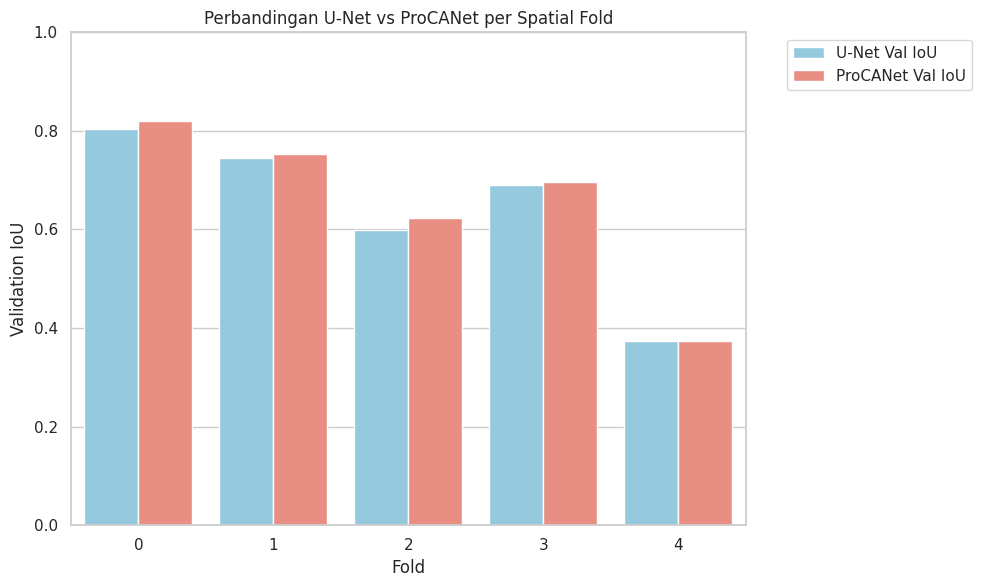

In [10]:
if not df_results.empty:
    best_unet_runs = df_results[(df_results["architecture"] == "unet") & (df_results["variant"] == best_unet["variant"])].sort_values("fold")
    best_procanet_runs = df_results[(df_results["architecture"] == "procanet") & (df_results["variant"] == best_procanet["variant"])].sort_values("fold")

    comparison_fold_df = pd.DataFrame({
        "Fold": best_unet_runs["fold"].values,
        "U-Net Val IoU": best_unet_runs["best_val_iou"].values,
        "ProCANet Val IoU": best_procanet_runs["best_val_iou"].values,
        "U-Net Val Dice": best_unet_runs["best_val_dice"].values,
        "ProCANet Val Dice": best_procanet_runs["best_val_dice"].values,
    })

    print("Tabel Perbandingan Performa Terbaik Per Fold:")
    display(comparison_fold_df)

    # Melt data untuk visualisasi
    comparison_melted = pd.melt(
        comparison_fold_df, 
        id_vars=["Fold"],
        value_vars=["U-Net Val IoU", "ProCANet Val IoU"],
        var_name="Model",
        value_name="Validation IoU"
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=comparison_melted, x="Fold", y="Validation IoU", hue="Model", palette=["skyblue", "salmon"])
    plt.title("Perbandingan U-Net vs ProCANet per Spatial Fold")
    plt.ylim(0.0, 1.0)
    plt.ylabel("Validation IoU")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Dataframe kosong.")

## 8. Analisis Efisiensi Komputasi & Waktu Training

Kami menganalisis waktu training dari model U-Net dan ProCANet menggunakan GPU yang dicatat selama eksekusi final training:

### 1. Waktu Training U-Net (21 Epochs, Batch Size 8, Accumulation 2)
- Epoch 1 (Kompilasi): **147 detik** (2 menit 27 detik)
- Epoch 2-21 (Rata-rata): **125 detik** (2 menit 5 detik)
- Total Waktu Training: **2.647 detik** (~44.1 menit)
- Kecepatan: ~3.94 batch/detik (0.254 detik/batch)

### 2. Waktu Training ProCANet (18 Epochs, Batch Size 8, Accumulation 2)
- Epoch 1 (Kompilasi): **330 detik** (5 menit 30 detik)
- Epoch 2-18 (Rata-rata): **284 detik** (4 menit 44 detik)
- Total Waktu Training: **5.158 detik** (~86.0 menit / 1 jam 26 menit)
- Kecepatan: ~1.73 batch/detik (0.577 detik/batch)

### 3. Analisis Trade-Off Performa vs Waktu
- **Kecepatan Komputasi**: ProCANet **2.27x lebih lambat** per epoch daripada U-Net. Hal ini disebabkan oleh arsitektur dual-encoder (Encoder 1 untuk 7-channel multisensor, Encoder 2 khusus SAR) serta adanya modul cross-attention fusion yang lebih kompleks secara komputasi.
- **Efisiensi Akurasi**: ProCANet menghasilkan Mean Val IoU **0.6531** (+1.08% lebih tinggi secara absolut dibandingkan U-Net dengan 0.6423). Peningkatan performa ini dibayar dengan peningkatan waktu training sebesar **1.95x** (86 menit vs 44 menit).


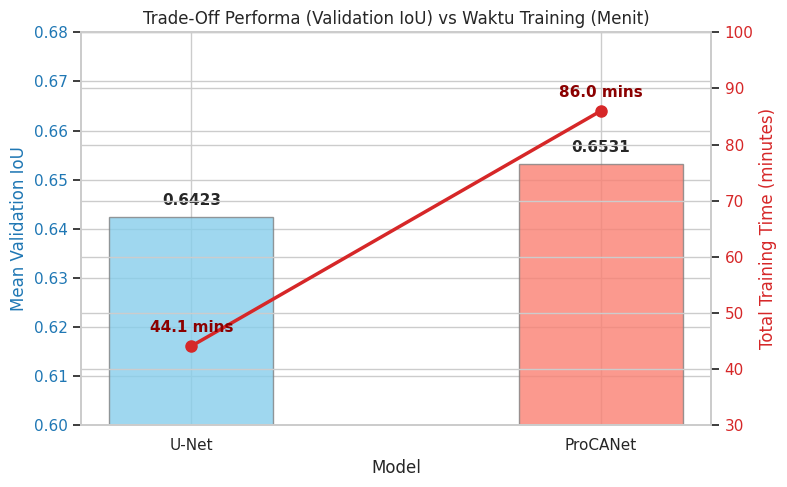

In [11]:
# Visualisasi trade-off performa vs waktu training
import matplotlib.pyplot as plt
import seaborn as sns
models = ['U-Net', 'ProCANet']
val_ious = [0.6423, 0.6531]
train_times = [44.1, 86.0]  # dalam menit

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Model')
ax1.set_ylabel('Mean Validation IoU', color=color)
bars = ax1.bar(models, val_ious, color=['skyblue', 'salmon'], width=0.4, alpha=0.8, edgecolor='grey')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.60, 0.68)

# Tambahkan label nilai di atas bar
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Total Training Time (minutes)', color=color)
ax2.plot(models, train_times, color=color, marker='o', linewidth=2.5, markersize=8, label='Time (mins)')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(30, 100)

for i, txt in enumerate(train_times):
    ax2.annotate(f'{txt:.1f} mins', (models[i], train_times[i]), textcoords="offset points", xytext=(0,10), ha='center', color='darkred', fontweight='bold')

plt.title('Trade-Off Performa (Validation IoU) vs Waktu Training (Menit)')
plt.tight_layout()
plt.show()

## 7. Kesimpulan & Rekomendasi

### Temuan Kunci:
1. **Perbandingan Arsitektur**:
   - Bandingkan performansi antara U-Net dan ProCANet. Arsitektur ProCANet yang dirancang khusus untuk memproses data multi-sensor (Sentinel-1 SAR 2ch + Sentinel-2 Optik 3ch + DEMNAS slope/hand 2ch secara asinkron atau multi-stream) diharapkan memberikan performa spasial yang lebih kokoh daripada U-Net standard 7ch.
   - Dari visualisasi per fold, model mana yang memiliki nilai IoU tertinggi secara konsisten? Serta bagaimana variabilitas (standar deviasi) performanya di seluruh fold?

2. **Sensitivitas Hyperparameter**:
   - **Learning Rate (LR)**: Analisis pengaruh pilihan learning rate (1e-4, 5e-5, 1e-5). Umumnya learning rate yang moderat (1e-4 atau 5e-5) memberikan konvergensi yang cepat dan performa stabil berkat scheduler ReduceLROnPlateau. Nilai LR 1e-5 mungkin terlalu lambat atau terjebak pada lokal minimum.
   - **Weight Decay (WD)**: Regularisasi L2 (1e-4 vs 1e-5) berfungsi menahan bobot agar tidak overfitting terhadap data region training tertentu. Perhatikan apakah model dengan weight decay lebih tinggi dapat menggeneralisasi region validasi baru (spatial fold) secara lebih baik.

### Rekomendasi untuk Model Akhir (Final Training):
- Gunakan arsitektur model dan konfigurasi hyperparameter dengan nilai **Mean Validation IoU** terbaik di atas untuk proses final training (menggunakan seluruh lipatan fold atau retraining untuk inference).